# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

The [U.S. Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data](https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ) contains 611,735 reported domestic flight records for May 2026. Completed, non-diverted flights with recorded values for all five selected features were eligible for this lab. Canceled flights, diverted flights, and records missing any selected feature were excluded before the sample was drawn.

The dataset is a reproducible random sample of 5,000 eligible flights. Each observation represents one completed, non-diverted domestic flight in that sample. Because incomplete records were removed before sampling, finding no missing values in the dataset does not mean that the original BTS data had no missing values. Conclusions from this sample describe the eligible flights and should not automatically be generalized to canceled or diverted flights.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [2]:
# Write your code here.
import pandas as pd

flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")

Display the first five rows of the DataFrame.


In [3]:
# Write your code here.
flights.head()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [4]:
# Write your code here.
flights.tail()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [5]:
# Write your code here.
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   airline                5000 non-null   object
 1   origin_city            5000 non-null   object
 2   destination_city       5000 non-null   object
 3   distance_miles         5000 non-null   int64 
 4   arrival_delay_minutes  5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


**How many observations are in the DataFrame?**

Your answer: 5,000 observations.


Count the missing values in every feature.


In [6]:
# Write your code here.
flights.isnull().sum()

airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type and feature type of each feature.**

| Feature | Pandas data type | Feature type |
| --- | --- | --- |
| `airline` | `object` | Categorical |
| `origin_city` | `object` | Categorical |
| `destination_city` | `object` | Categorical |
| `distance_miles` | `int64` | Quantitative |
| `arrival_delay_minutes` | `int64` | Quantitative |

## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [7]:
# Write your code here.
destination_counts = flights["destination_city"].value_counts()
destination_counts

destination_city
Chicago, IL                       296
Atlanta, GA                       222
Dallas/Fort Worth, TX             210
Denver, CO                        209
Washington, DC                    165
                                 ... 
Gunnison, CO                        1
Allentown/Bethlehem/Easton, PA      1
Idaho Falls, ID                     1
Jamestown, ND                       1
Yuma, AZ                            1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


Matplotlib is building the font cache; this may take a moment.


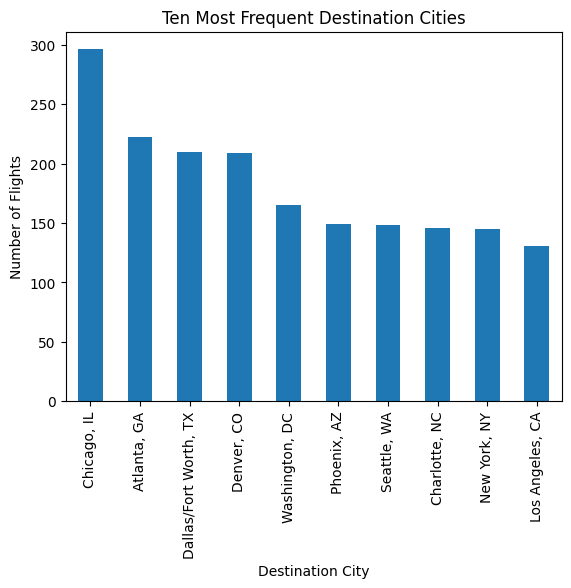

In [8]:
# Write your code here.
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind="bar")

plt.title("Ten Most Frequent Destination Cities")
plt.xlabel("Destination City")
plt.ylabel("Number of Flights")

plt.show()

**Which destination city is most common in the sample?**

Your answer: Chicago, IL is the most common destination city in the sample, with 296 flights.


## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


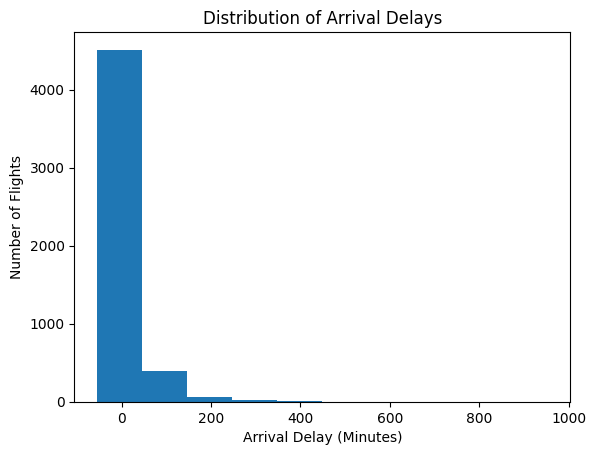

In [9]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind="hist")

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

**Approximately what arrival-delay value appears most common?**

Your answer: Around 0 minutes


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer: Approximately -50 to 950 minutes


**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer: The distribution is skewed to the right


Display a numerical summary of `arrival_delay_minutes`.


In [10]:
# Write your code here.
flights["arrival_delay_minutes"].describe()

count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [11]:
# Write your code here.
flights["arrival_delay_minutes"].mode()

0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: The calculated mode was -8 minutes, which was close to my estimate of around 0 minutes from the histogram.


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer: They matched closely. I estimated about -50 to 950 minutes, while the actual minimum was -55 and the maximum was 953 minutes.


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: The mean is greater than the median.


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: The mean is greater than the median because the large positive delays pull the mean to the right, which matches the right-skewed shape of the histogram.


## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


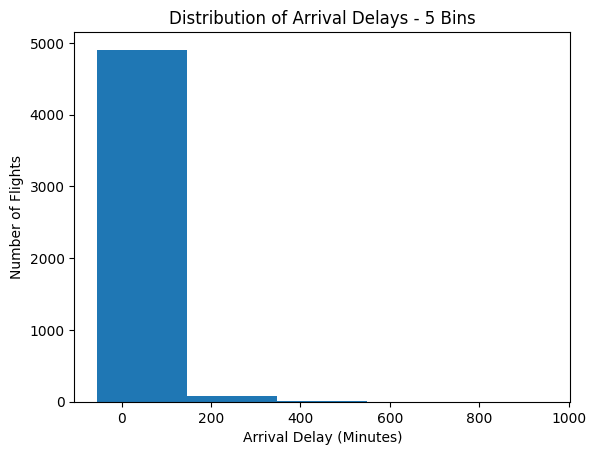

In [12]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind="hist", bins=5)

plt.title("Distribution of Arrival Delays - 5 Bins")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


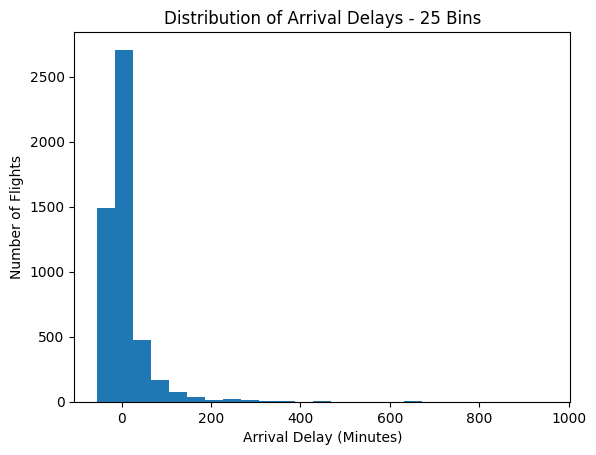

In [13]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind="hist", bins=25)

plt.title("Distribution of Arrival Delays - 25 Bins")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

**What changed when the number of bins was reduced to 5?**

Your answer: The histogram showed less detail because more arrival-delay values were grouped together into each bin.


**What changed when the number of bins was increased to 25?**

Your answer: The histogram showed more detail, making the shape of the distribution and the long right tail easier to see.


**Which bin setting communicates the distribution most clearly?**

Your answer: I think 25 bins communicates the distribution most clearly because it shows more detail while still making the overall right-skewed shape easy to see.


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


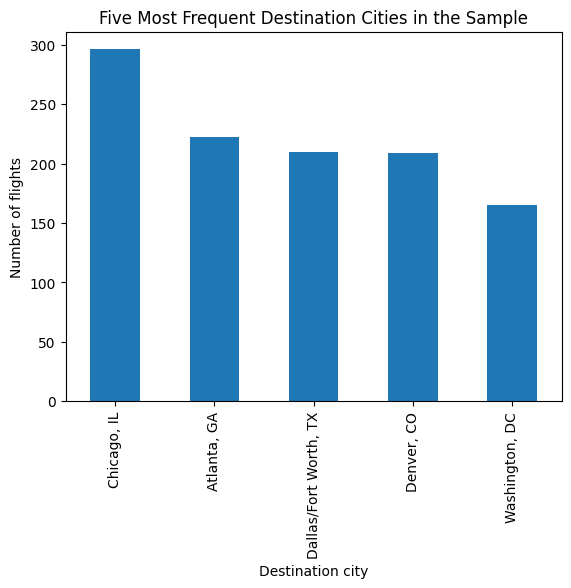

In [14]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


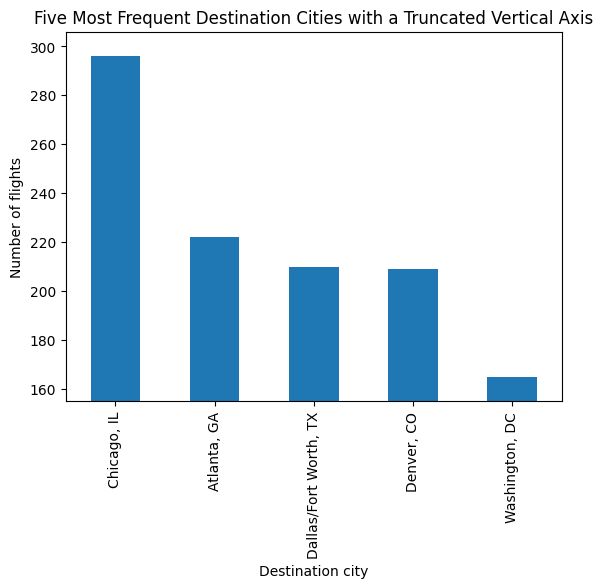

In [15]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: The truncated axis makes the differences between the destination cities appear much larger than they actually are.


**Which chart communicates the counts more honestly?**

Your answer: The first chart communicates the counts more honestly because the vertical axis starts at zero.


## Is this sample representative?

Review the dataset description at the top of the lab before answering these questions.


**What time period is represented by the source data?**

Your answer: May 2026.


**Which flights were eligible to be included in the sample?**

Your answer: Completed, non-diverted domestic flights with recorded values for all five features.


**Which flights and records were excluded before the sample was selected?**

Your answer: Canceled flights, diverted flights, and records missing any of the selected features.


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer: No, because records with missing values were removed before the sample was selected.


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: Because canceled and diverted flights were not included in the sample, so the results may not represent them.


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. These questions use features that you did not visualize earlier in the lab.


**Which chart would you use to show the frequency of each airline?**

Your answer: I would use a bar chart because it makes it easy to compare the number of flights for each airline.


**Which chart would you use to show what share of sampled flights departed from each origin city?**

Your answer: I would use a pie chart because it shows the share of flights from each origin city.


**Which chart would you use to show the distribution of flight distances?**

Your answer: I would use a histogram because flight distance is quantitative data and a histogram shows how the values are distributed.


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used: ChatGPT
- What I asked it to help with: I used it to help me understand some of the instructions and check my Python code.
- One suggestion I checked against my code, chart, or output: I checked the suggested interpretation of the arrival delay histogram against the chart and the numerical summary.
- What I accepted, modified, or rejected—and why: I accepted the suggestion because the values and the shape of my histogram supported the explanation.

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response:


## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The AI-use reflection is complete and honest.
